# 02 · Overall model test and a single alternative hypothesis

**Objective:** Compute the OMT statistic T0 for H0, decide whether to reject it, then test one alternative (e.g. a seasonal term) by hand using the B-method noncentrality/critical-value machinery in `testing.py`.

Related blog post: https://jsempereh.github.io/notes/insar-model-selection/


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from insar_mht import library, hypotheses, testing, dia, rpn, unwrap, reliability
from insar_mht.io import egms


In [2]:
from scipy import stats

ds = egms.load_cached(
    "../data/processed/alicante_marina_metadata.parquet",
    "../data/processed/alicante_marina_displacements.parquet",
)

# Same point as notebook 01 (strongest linear trend in the AOI)
pid = ds.metadata.loc[ds.metadata["mean_velocity"].abs().idxmax(), "pid"]
t, y = egms.point_time_series(ds, pid)

A0 = library.design_matrix_h0(t)
sigma = 3.0  # mm
Qyy = (sigma ** 2) * np.eye(len(t))
Qyy_inv = np.linalg.inv(Qyy)
h0_fit = testing.gls_fit(y, A0, Qyy_inv)

alpha0 = 1 / (2 * len(t))
q0 = len(t) - A0.shape[1]
T0 = testing.omt_statistic(h0_fit.e_hat, Qyy_inv)
K = stats.chi2.ppf(1 - alpha0, q0)
print(f"point {pid}: T0={T0:.1f}, K={K:.1f} -> {'REJECTED' if T0 > K else 'sustained'}")

point 48GPP2M1IM: T0=443.9, K=271.4 -> REJECTED


## One alternative hypothesis: seasonal motion

H0 was rejected: the residual has structure. A 1-year seasonal term
(M3, Eq. 14) is a reasonable first alternative to test:

    Hj: E[y] = A0*v + C*[s, c]',  q = 2

`C` is built from `library.m3_seasonal(t)` and is fixed (known); only the
test statistic uses it here, no need to actually fit Hj yet to screen it.

In [3]:
sin_col, cos_col = library.m3_seasonal(t)
C_seasonal = np.column_stack([sin_col, cos_col])
q_seasonal = C_seasonal.shape[1]

L_seasonal = testing.l_matrix(C_seasonal, Qyy_inv, h0_fit.q_ehat_ehat)
Tq_seasonal = testing.test_statistic(h0_fit.e_hat, L_seasonal)
print(f"T_seasonal = {Tq_seasonal:.1f} (q={q_seasonal})")

T_seasonal = 13.8 (q=2)


## B-method calibration

`T_seasonal` (q=2) and `T0`'s critical value (q=q0) aren't directly
comparable: different degrees of freedom. Section II-B fixes this: pick a
reference power `gamma0` and a reference significance `alpha0` at q=1,
derive the noncentrality `lambda0` that gives that power, then for any
other dimension `q` find the `alpha_j` that reproduces the *same* power at
`lambda0`. The resulting critical value is what makes test ratios (Eq. 6)
comparable across hypotheses of different size.

In [4]:
gamma0 = 0.5  # Section II-E: "just enough to flip the decision", not particularly sensitive
lambda0 = testing.noncentrality_from_power(gamma0, alpha0, q=1)

alpha_seasonal = testing.alpha_for_matched_power(lambda0, gamma0, q=q_seasonal)
critical_value_seasonal = stats.chi2.ppf(1 - alpha_seasonal, q_seasonal)
ratio_seasonal = testing.test_ratio(Tq_seasonal, q=q_seasonal, alpha=alpha_seasonal)

print(f"lambda0 = {lambda0:.2f}  (from alpha0={alpha0:.2e}, gamma0={gamma0}, q=1)")
print(f"alpha_seasonal = {alpha_seasonal:.2e}  ->  critical value = {critical_value_seasonal:.1f}")
print(f"test ratio = {ratio_seasonal:.2f}  -> {'seasonal favored over H0' if ratio_seasonal > 1 else 'not more likely than H0'}")

lambda0 = 9.23  (from alpha0=2.38e-03, gamma0=0.5, q=1)
alpha_seasonal = 5.95e-03  ->  critical value = 10.2
test ratio = 1.34  -> seasonal favored over H0


## If favored, actually fit it and look

The test ratio only screens the hypothesis; the augmented model still needs
its own GLS fit (Eq. 11) to get usable parameter estimates and amplitude.

v_hat = -8.87 mm/yr, amplitude = 0.96 mm, phase offset t0 = -0.41 yr
residual sum of squares: H0=3995  seasonal=3871


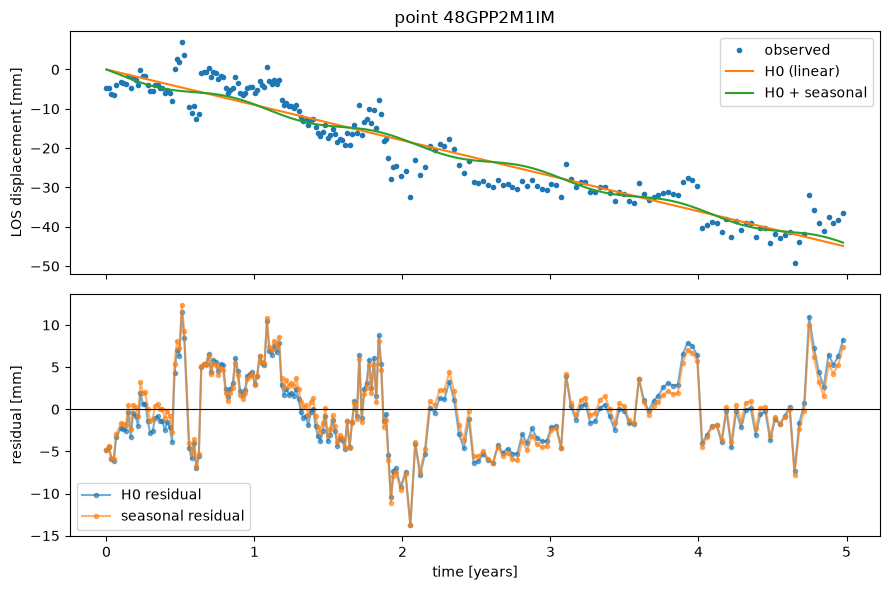

In [5]:
A_aug = np.column_stack([A0, C_seasonal])
aug_fit = testing.gls_fit(y, A_aug, Qyy_inv)
v_hat, s_hat, c_hat = aug_fit.x_hat
amplitude = np.hypot(s_hat, c_hat)
t0_offset = -np.sign(c_hat) * np.arccos(s_hat / amplitude) / (2 * np.pi)  # Section II-D

print(f"v_hat = {v_hat:.2f} mm/yr, amplitude = {amplitude:.2f} mm, phase offset t0 = {t0_offset:.2f} yr")
print(f"residual sum of squares: H0={np.sum(h0_fit.e_hat**2):.0f}  seasonal={np.sum(aug_fit.e_hat**2):.0f}")

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(t, y, ".", label="observed")
axes[0].plot(t, h0_fit.y_hat, "-", label="H0 (linear)")
axes[0].plot(t, aug_fit.y_hat, "-", label="H0 + seasonal")
axes[0].set_ylabel("LOS displacement [mm]"); axes[0].legend(); axes[0].set_title(f"point {pid}")

axes[1].plot(t, h0_fit.e_hat, ".-", label="H0 residual", alpha=0.6)
axes[1].plot(t, aug_fit.e_hat, ".-", label="seasonal residual", alpha=0.6)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xlabel("time [years]"); axes[1].set_ylabel("residual [mm]"); axes[1].legend()
plt.tight_layout()


Test ratio = 1.34 > 1, so seasonal is technically favored over H0. But the
amplitude is only ~1mm and RSS barely drops (3995 -> 3871, ~3%). Bucketing
the H0 residual by year shows why: year 2 has mean residual -3.9mm against
~0-1mm for the other years, a one-off dip, not a repeating annual cycle. A
real seasonal signal would show a similar-sized wiggle every year.

This points to a discrete event (M5 outlier or M6 step) around year 2
rather than seasonality. Notebook 04 runs the whole library and picks the
actual best model by test ratio, instead of testing one guessed hypothesis.